In [24]:

import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def load_experiments_csv(force_csv_path=None, candidate_dirs=None):
    """Load experiments CSV, preferring the latest complete 4-experiment run."""
    if candidate_dirs is None:
        candidate_dirs = [Path('../thesis_experiment'), Path('thesis_experiment')]

    candidates = []
    for d in candidate_dirs:
        if d.exists():
            candidates.extend(d.glob('experiments_*.csv'))

    candidates = sorted(set(candidates), key=lambda p: p.stat().st_mtime, reverse=True)
    if not candidates:
        raise FileNotFoundError('No experiments CSV found in thesis_experiment/')

    def inspect_candidate(path: Path):
        try:
            tmp = pd.read_csv(path, encoding='utf-8-sig')
        except Exception:
            return {
                'path': str(path),
                'rows': 0,
                'mtime': path.stat().st_mtime,
                'exp_codes': [],
                'has_all_4': False,
                'tasks_per_exp_min': 0,
            }

        exp_codes = []
        if 'experiment_name' in tmp.columns:
            for x in tmp['experiment_name'].dropna().astype(str):
                m = re.search(r'(exp0[1-4])', x)
                if m:
                    exp_codes.append(m.group(1))

        exp_set = sorted(set(exp_codes))
        has_all_4 = all(e in exp_set for e in EXP_ORDER)

        tasks_per_exp_min = 0
        if 'experiment_name' in tmp.columns and 'task_id' in tmp.columns and len(tmp):
            grp = tmp.assign(exp_code=tmp['experiment_name'].astype(str).str.extract(r'(exp0[1-4])', expand=False))
            grp = grp[grp['exp_code'].isin(EXP_ORDER)]
            if len(grp):
                tasks_per_exp = grp.groupby('exp_code')['task_id'].nunique()
                tasks_per_exp_min = int(tasks_per_exp.min()) if len(tasks_per_exp) else 0

        return {
            'path': str(path),
            'rows': int(len(tmp)),
            'mtime': path.stat().st_mtime,
            'exp_codes': exp_set,
            'has_all_4': bool(has_all_4),
            'tasks_per_exp_min': tasks_per_exp_min,
        }

    meta = pd.DataFrame([inspect_candidate(p) for p in candidates])
    meta['mtime'] = pd.to_datetime(meta['mtime'], unit='s')
    meta = meta.sort_values('mtime', ascending=False)

    if force_csv_path:
        csv_path = Path(force_csv_path)
    else:
        complete = meta[meta['has_all_4']].copy()
        if len(complete):
            complete = complete.sort_values(['mtime', 'rows'], ascending=[False, False])
            csv_path = Path(complete.iloc[0]['path'])
        else:
            csv_path = Path(meta.iloc[0]['path'])

    df_raw = pd.read_csv(csv_path, encoding='utf-8-sig')
    return csv_path, df_raw, meta

def extract_cfg_value(cfg_obj, path, default=np.nan):
    cur = cfg_obj
    for p in path:
        if not isinstance(cur, dict) or p not in cur:
            return default
        cur = cur[p]
    return cur

def infer_memory_mode(row):
    v = row.get('cfg_initialize_memory', np.nan)
    if not pd.isna(v):
        return 'cold' if bool(v) else 'warm'
    return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('memory_mode', 'unknown')

def preprocess_experiments(df_raw):
    """Normalize schema and derive analysis-ready columns."""
    df = df_raw.copy()

    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    if 'success' in df.columns:
        df['success_bool'] = df['success'].map(to_bool)
    else:
        df['success_bool'] = False

    if 'status' in df.columns:
        df['status_norm'] = df['status'].astype(str).str.upper().str.strip()
    else:
        df['status_norm'] = 'UNKNOWN'

    if 'experiment_name' in df.columns:
        df['exp_name_raw'] = df['experiment_name'].fillna('unknown')
    else:
        df['exp_name_raw'] = 'unknown'

    df['exp_code'] = df['exp_name_raw'].map(canonical_exp)
    df['exp_label'] = df['exp_code'].map(EXP_LABELS).fillna(df['exp_name_raw'])

    if df['exp_code'].isin(EXP_ORDER).any():
        df = df[df['exp_code'].isin(EXP_ORDER)].copy()

    df['cfg_obj'] = [{} for _ in range(len(df))]
    if 'experiment_config_json' in df.columns:
        parsed = []
        for v in df['experiment_config_json']:
            try:
                parsed.append(json.loads(v) if isinstance(v, str) and v.strip() else {})
            except Exception:
                parsed.append({})
        df['cfg_obj'] = parsed

    df['cfg_initialize_memory'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['memory_settings', 'initialize_memory']))
    df['cfg_memory_name'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['memory_settings', 'memory_name']))
    df['cfg_use_vision'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['perception_settings', 'use_vision']))
    df['cfg_include_invisible'] = df['cfg_obj'].map(lambda o: extract_cfg_value(o, ['perception_settings', 'a11y_extractor_settings', 'include_invisible']))
    df['cfg_keep_only_active_window_nodes'] = df['cfg_obj'].map(
        lambda o: extract_cfg_value(o, ['perception_settings', 'a11y_extractor_settings', 'keep_only_active_window_nodes'])
    )

    df['experiment_max_cycles_num'] = df['experiment_max_cycles'].map(to_num) if 'experiment_max_cycles' in df.columns else np.nan

    numeric_cols = [
        'chunks_total', 'chunks_success', 'chunks_fail', 'chunk_success_rate', 'steps_total', 'steps_success', 'steps_fail',
        'step_success_rate', 'total_planned_pause_sec', 'avg_pause_per_step_sec', 'episode_duration_sec',
        'recovery_after_fail_rate', 'recoveries_after_fail_total', 'recoveries_after_fail_opportunities',
        'first_failure_chunk_index', 'max_consecutive_chunk_failures', 'planner_done_judge_fail', 'planner_fail_judge_success',
        'llm_requests_total',
    ]
    for c in numeric_cols:
        if c in df.columns:
            df[c] = df[c].map(to_num)

    for c in ['failure_type_counts', 'action_type_counts', 'decision_counts']:
        if c in df.columns:
            df[c] = df[c].map(parse_counter_cell)

    df['memory_mode'] = df.apply(infer_memory_mode, axis=1)
    df['vision_mode'] = df.apply(infer_vision_mode, axis=1)
    df['memory_label'] = df['memory_mode'].map({'cold': 'Cold', 'warm': 'Warm'}).fillna('Unknown')
    df['vision_label'] = df['vision_mode'].map({'on': 'Vision ON', 'off': 'Vision OFF'}).fillna('Vision ?')
    df['condition_2x2'] = df['memory_label'] + ' | ' + df['vision_label']

    df['exp_sort'] = df['exp_code'].apply(lambda x: EXP_ORDER.index(x) if x in EXP_ORDER else 999)
    df = df.sort_values(['exp_sort', 'timestamp'], kind='stable').reset_index(drop=True)

    print('Filtered rows:', len(df))
    print('Experiments found:', sorted(df['exp_code'].unique()))
    return df 

def to_bool(v):
    if pd.isna(v):
        return False
    if isinstance(v, bool):
        return v
    s = str(v).strip().lower()
    return s in {'1', 'true', 'yes', 'y'}


def canonical_exp(name):
    s = str(name or '')
    m = re.search(r'(exp0[1-4])', s)
    return m.group(1) if m else 'other'
def to_num(v):
    try:
        return float(v)
    except Exception:
        return np.nan


def parse_counter_cell(v):
    if isinstance(v, dict):
        return v
    if pd.isna(v):
        return {}
    s = str(v).strip()
    if not s:
        return {}
    try:
        out = json.loads(s)
        if isinstance(out, dict):
            return out
    except Exception:
        pass
    try:
        out = ast.literal_eval(s)
        if isinstance(out, dict):
            return out
    except Exception:
        pass
    return {}

    
def infer_memory_mode(row):
    v = row.get('cfg_initialize_memory', np.nan)
    if not pd.isna(v):
        return 'cold' if bool(v) else 'warm'
    return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('memory_mode', 'unknown')


def infer_vision_mode(row):
    v = row.get('cfg_use_vision', np.nan)
    if not pd.isna(v):
        return 'on' if bool(v) else 'off'
    return EXP_FACTOR_MAP.get(row.get('exp_code'), {}).get('vision_mode', 'unknown')


def wilson_ci(k, n, z=1.96):
    if n <= 0:
        return np.nan, np.nan
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return center - half, center + half

In [25]:
EXP_ORDER = ['exp01', 'exp02', 'exp03', 'exp04']
EXP_LABELS = {
    'exp01': 'Exp01 Cold + Vision ON',
    'exp02': 'Exp02 Warm + Vision ON',
    'exp03': 'Exp03 Cold + Vision OFF',
    'exp04': 'Exp04 Warm + Vision OFF',
}

EXP_FACTOR_MAP = {
    'exp01': {'memory_mode': 'cold', 'vision_mode': 'on'},
    'exp02': {'memory_mode': 'warm', 'vision_mode': 'on'},
    'exp03': {'memory_mode': 'cold', 'vision_mode': 'off'},
    'exp04': {'memory_mode': 'warm', 'vision_mode': 'off'},
}

SAVE_FIGURES = False
FIG_DIR = Path('../thesis_experiment/figures')

FORCE_CSV_PATH1 = "../thesis_experiment/experiments_final_v1_20260227_160645.csv"
FORCE_CSV_PATH2 = "../thesis_experiment/experiments_final_v1_20260228_104054.csv"
FORCE_CSV_PATH3 = "../thesis_experiment/experiments_final_v1_20260228_164937.csv"

CSV_PATH1, df_raw1, candidate_meta1 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH1)
CSV_PATH2, df_raw2, candidate_meta2 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH2)
CSV_PATH3, df_raw3, candidate_meta3 = load_experiments_csv(force_csv_path=FORCE_CSV_PATH3)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

FIG_DIR = "figures_thesis"
os.makedirs(FIG_DIR, exist_ok=True)

# Expect df_all already built as in previous cell
# Required columns (as in your preprocess): 
#   task_id, condition_2x2, run_id, success_bool,
#   chunk_success_rate, chunks_total, chunks_success, chunks_fail,
#   steps_success, steps_fail, steps_total, step_success_rate,
#   total_planned_pause_sec, avg_pause_per_step_sec,
#   recovery_after_fail_rate, recoveries_after_fail_total, recoveries_after_fail_opportunities,
#   status_norm, planner_done_judge_fail, planner_fail_judge_success,
#   action_type_counts, decision_counts

COND_COL = "condition_2x2"
TASK_COL = "task_id"
display(candidate_meta1[['path', 'rows', 'has_all_4', 'tasks_per_exp_min', 'exp_codes', 'mtime']].head(12))
print(f'Using CSV: {CSV_PATH1}')
print(f'Rows: {len(df_raw1)} | Columns: {len(df_raw1.columns)}')
df1 = preprocess_experiments(df_raw1)
df2 = preprocess_experiments(df_raw2)
df3 = preprocess_experiments(df_raw3)

#df[['exp_code', 'exp_label', 'task_id', 'status_norm', 'success_bool']].head(50)

#df_raw1.head(50)


,path,rows,has_all_4,tasks_per_exp_min,exp_codes,mtime
0,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-03-01 16:34:18.922861099
1,..\thesis_experiment\experiments_final.csv,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 14:34:56.724273205
2,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 13:31:38.653462887
3,..\thesis_experiment\experiments_final_v1_2026...,40,True,10,"[exp01, exp02, exp03, exp04]",2026-02-28 08:55:17.757168293


Using CSV: ..\thesis_experiment\experiments_final_v1_20260227_160645.csv
Rows: 40 | Columns: 79
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']
Filtered rows: 40
Experiments found: ['exp01', 'exp02', 'exp03', 'exp04']


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def _truncate_cmap(cmap, minval=0.15, maxval=0.80, n=256):
    new_colors = cmap(np.linspace(minval, maxval, n))
    return mcolors.LinearSegmentedColormap.from_list("trunc", new_colors)

def plot_task_condition_success_heatmap_light_continuous(
    df,
    outpath_png=None,
    outpath_pdf=None,
    annotate=True,
    figsize=(12.2, 6.2),
    task_id_chars=22,
    cell_fontsize=12,          # bigger cell numbers
    ytick_fontsize=11,
    xtick_fontsize=14,
    axis_label_fontsize=16,    # bigger axis labels (Task + colorbar label)
    xlabels_two_lines=True,
    title="",
    title_fontsize = 22
):
    g = (
        df.groupby(["run_id", "task_id", "condition_2x2"])["success_bool"]
          .mean()
          .reset_index(name="run_rate")
    )
    m = g.groupby(["task_id", "condition_2x2"])["run_rate"].mean().reset_index(name="mean_rate")
    pivot = m.pivot(index="task_id", columns="condition_2x2", values="mean_rate").fillna(0.0)

    pivot = pivot.loc[sorted(pivot.index.astype(str))]
    Z = pivot.to_numpy()

    base = plt.get_cmap("Blues")
    cmap = _truncate_cmap(base, 0.10, 0.70)
    norm = mcolors.Normalize(vmin=0, vmax=1)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(Z, cmap=cmap, norm=norm, aspect="auto", interpolation="nearest")

    # No title (as requested)
    ax.set_xlabel("")
    ax.set_ylabel("Task", fontsize=axis_label_fontsize, labelpad=12)
    ax.set_title(title, fontsize=title_fontsize )
    ax.set_xticks(np.arange(pivot.shape[1]))
    xlabels = [str(c) for c in pivot.columns]
    if xlabels_two_lines:
        new_labels = []
        for s in xlabels:
            s = str(s)
            if "|" in s:
                a, b = [p.strip() for p in s.split("|", 1)]
                new_labels.append(a + "\n" + b)
            else:
                new_labels.append(s.replace(" ", "\n", 1))
        xlabels = new_labels

    ax.set_xticklabels(xlabels, rotation=0, ha="center", fontsize=xtick_fontsize)
    ax.tick_params(axis="x", pad=10)
    ax.tick_params(length=0)

    ylabels = [str(t)[:task_id_chars] + ("…" if len(str(t)) > task_id_chars else "") for t in pivot.index]
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(ylabels, fontsize=ytick_fontsize)
    ax.tick_params(axis="y", pad=8)

    if annotate:
        for i in range(Z.shape[0]):
            for j in range(Z.shape[1]):
                ax.text(j, i, f"{Z[i, j]:.2f}", ha="center", va="center", fontsize=cell_fontsize)

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("Success rate", fontsize=axis_label_fontsize, labelpad=12)
    cbar.ax.tick_params(labelsize=12)
    
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.18)

    if outpath_png:
        fig.savefig(outpath_png, dpi=300)

    return fig, ax, pivot

import os
import numpy as np
import matplotlib.pyplot as plt

def plot_chunk_dashboard_v3(
    df,
    outpath_png=None,
    outpath_pdf=None,
    title="Chunk-level diagnostics across conditions",

    # layout generale
    figsize=(20, 13),
    width_ratios=(1.08, 1.18),
    height_ratios=(1.08, 1.08),
    hspace=0.42,
    wspace=0.24,
    tight_layout_rect=(0, 0, 1, 0.95),

    # barre / marker / linee
    bar_width=0.62,
    bar_edgecolor="black",
    bar_linewidth=0.6,
    err_capsize=5,
    scatter_size=48,
    scatter_alpha=0.95,
    scatter_edgecolor="white",
    scatter_linewidth=0.6,
    jitter_frac=0.40,

    # colori
    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",

    # font
    suptitle_fontsize=24,
    panel_title_fontsize=18,
    ylabel_fontsize=14,
    xtick_fontsize=12,
    ytick_fontsize=12,
    legend_fontsize=11,

    # titolo / legenda
    suptitle_y=0.98,
    title_pad=0,
    title_y=1.18,
    legend_outside=True,
    legend_y=1.08,
    legend_ncol=2,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,

    # labels asse x
    xlabels_two_lines=True,

    # assi / griglia
    xtick_rotation=0,
    xtick_pad=8,
    grid_alpha=0.25,
    ypad_top=0.06,
    ylim_a_max=1.15,

    # salvataggio
    save_dpi=350,
):
    conds = sorted(df[COND_COL].dropna().astype(str).unique().tolist())
    x = np.arange(len(conds))

    # --- X labels come nella dashboard steps ---
    xlabels = [str(c) for c in conds]
    if xlabels_two_lines:
        tmp = []
        for s in xlabels:
            if "|" in s:
                a, b = [p.strip() for p in s.split("|", 1)]
                tmp.append(a + "\n" + b)
            else:
                tmp.append(s.replace(" ", "\n", 1))
        xlabels = tmp

    # --- Aggregations ---
    g_run_rc = (
        df.groupby(["run_id", COND_COL])["chunk_success_rate"]
          .mean()
          .reset_index(name="run_mean_rc")
    )
    rc = g_run_rc.groupby(COND_COL)["run_mean_rc"].agg(["mean", "std"]).reindex(conds)

    g_task_rc = (
        df.groupby([TASK_COL, COND_COL])["chunk_success_rate"]
          .mean()
          .reset_index(name="task_mean_rc")
    )

    g_run_cnt = (
        df.groupby(["run_id", COND_COL])[["chunks_success", "chunks_fail"]]
          .mean()
          .reset_index()
    )
    cnt = g_run_cnt.groupby(COND_COL)[["chunks_success", "chunks_fail"]].mean().reindex(conds)

    g_run_dyn = (
        df.groupby(["run_id", COND_COL])[["first_failure_chunk_index", "max_consecutive_chunk_failures"]]
          .mean()
          .reset_index()
    )
    dyn_mean = g_run_dyn.groupby(COND_COL)[["first_failure_chunk_index", "max_consecutive_chunk_failures"]].mean().reindex(conds)
    dyn_std = g_run_dyn.groupby(COND_COL)[["first_failure_chunk_index", "max_consecutive_chunk_failures"]].std().reindex(conds).fillna(0)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2, 2,
        height_ratios=height_ratios,
        width_ratios=width_ratios,
        wspace=wspace,
        hspace=hspace
    )

    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    axD = fig.add_subplot(gs[1, 1])

    def _style_ax(ax):
        ax.grid(True, axis="y", alpha=grid_alpha)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", rotation=xtick_rotation, pad=xtick_pad, labelsize=xtick_fontsize)
        ax.tick_params(axis="y", labelsize=ytick_fontsize)
        for lab in ax.get_xticklabels():
            lab.set_ha("center")

    def _legend_between_title_and_plot(ax):
        ax.legend(
            loc="center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            columnspacing=legend_columnspacing,
            handlelength=legend_handlelength,
            handletextpad=legend_handletextpad,
            borderaxespad=0.0,
            labelspacing=legend_labelspacing,
        )

    # -------------------------
    # Panel A
    # -------------------------
    axA.bar(
        x,
        rc["mean"].fillna(0).to_numpy(),
        yerr=rc["std"].fillna(0).to_numpy(),
        capsize=err_capsize,
        width=bar_width,
        color=main_blue,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth
    )

    max_point = 0.0
    rng = np.random.default_rng(42)

    for i, c in enumerate(conds):
        vals = g_task_rc.loc[
            g_task_rc[COND_COL].astype(str) == c,
            "task_mean_rc"
        ].dropna().to_numpy()

        if len(vals):
            max_point = max(max_point, float(np.max(vals)))
            jitter = (rng.random(len(vals)) - 0.5) * (bar_width * jitter_frac)
            axA.scatter(
                np.full(len(vals), i) + jitter,
                vals,
                s=scatter_size,
                alpha=scatter_alpha,
                color=contrast_orange,
                edgecolors=scatter_edgecolor,
                linewidths=scatter_linewidth,
                zorder=3
            )

    top = max(1.0 + ypad_top, max_point + 0.03)
    axA.set_ylim(0, min(ylim_a_max, top))
    axA.set_xticks(x)
    axA.set_xticklabels(xlabels)
    axA.set_ylabel("Chunk success rate $r_c$", fontsize=ylabel_fontsize)
    axA.set_title("(a) Chunk quality ($r_c$)", fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axA)

    # -------------------------
    # Panel B
    # -------------------------
    succ = cnt["chunks_success"].fillna(0).to_numpy()
    fail = cnt["chunks_fail"].fillna(0).to_numpy()

    axB.bar(
        x, succ,
        width=bar_width,
        label="Chunks OK",
        color=blue_light,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth
    )

    axB.bar(
        x, fail,
        bottom=succ,
        width=bar_width,
        label="Chunks FAIL",
        color=blue_dark,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth
    )

    axB.set_xticks(x)
    axB.set_xticklabels(xlabels)
    axB.set_ylabel("Mean chunks per episode", fontsize=ylabel_fontsize)
    axB.set_title("(b) Chunk outcomes", fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axB)

    if legend_outside:
        _legend_between_title_and_plot(axB)
    else:
        axB.legend(frameon=False, fontsize=legend_fontsize)

    # -------------------------
    # Panel C
    # -------------------------
    axC.bar(
        x,
        dyn_mean["first_failure_chunk_index"].fillna(0).to_numpy(),
        yerr=dyn_std["first_failure_chunk_index"].fillna(0).to_numpy(),
        capsize=err_capsize,
        width=bar_width,
        color=main_blue,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth
    )
    axC.set_xticks(x)
    axC.set_xticklabels(xlabels)
    axC.set_ylabel("Mean index", fontsize=ylabel_fontsize)
    axC.set_title("(c) First failure position", fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axC)

    # -------------------------
    # Panel D
    # -------------------------
    axD.bar(
        x,
        dyn_mean["max_consecutive_chunk_failures"].fillna(0).to_numpy(),
        yerr=dyn_std["max_consecutive_chunk_failures"].fillna(0).to_numpy(),
        capsize=err_capsize,
        width=bar_width,
        color=main_blue,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth
    )
    axD.set_xticks(x)
    axD.set_xticklabels(xlabels)
    axD.set_ylabel("Mean max streak", fontsize=ylabel_fontsize)
    axD.set_title("(d) Failure persistence", fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axD)

    if title is not None:
        fig.suptitle(title, y=suptitle_y, fontsize=suptitle_fontsize)

    fig.tight_layout(rect=tight_layout_rect)

    if outpath_png:
        fig.savefig(outpath_png, dpi=save_dpi, bbox_inches="tight")


    return fig, (axA, axB, axC, axD)

import numpy as np
import pandas as pd

def _sum_counters(series):
    total = {}
    for v in series.dropna():
        if isinstance(v, dict):
            for k, c in v.items():
                total[str(k)] = total.get(str(k), 0) + float(c)
    return total

def build_steps_summary_table(df, cond_col="condition_2x2"):
    base_cols = [
        "steps_total", "steps_success", "steps_fail", "step_success_rate",
        "avg_pause_per_step_sec", "llm_requests_total"
    ]
    for c in base_cols:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    g_base = (
        df.groupby(["run_id", cond_col])[base_cols]
          .mean()
          .reset_index()
    )

    rows = []
    has_actions = "action_type_counts" in df.columns
    for (run_id, cond), sub in df.groupby(["run_id", cond_col], dropna=False):
        if not has_actions:
            rows.append({"run_id": run_id, cond_col: cond, "WAIT_share": np.nan, "PYTHON_share": np.nan})
            continue
        cnt = _sum_counters(sub["action_type_counts"])
        tot = sum(cnt.values()) if cnt else 0.0
        if tot <= 0:
            rows.append({"run_id": run_id, cond_col: cond, "WAIT_share": np.nan, "PYTHON_share": np.nan})
            continue
        rows.append({
            "run_id": run_id,
            cond_col: cond,
            "WAIT_share": cnt.get("WAIT", 0.0) / tot,
            "PYTHON_share": cnt.get("PYTHON", 0.0) / tot,
        })
    g_act = pd.DataFrame(rows)

    g = g_base.merge(g_act, on=["run_id", cond_col], how="left")
    agg = g.groupby(cond_col, dropna=False).mean(numeric_only=True).reset_index()

    def fmt_pct(x, decimals=1):
        return "-" if pd.isna(x) else f"{100*x:.{decimals}f}%"

    out = pd.DataFrame({
        "Condition": agg[cond_col].astype(str),
        "Step success rate $r_s$": agg["step_success_rate"].map(lambda v: fmt_pct(v, 1)),
        "Steps evaluated": agg["steps_total"].round(1),
        "Steps OK": agg["steps_success"].round(1),
        "Steps FAIL": agg["steps_fail"].round(1),
        "WAIT share": agg["WAIT_share"].map(lambda v: fmt_pct(v, 1)),
        "PYTHON share": agg["PYTHON_share"].map(lambda v: fmt_pct(v, 1)),
        "Avg pause/step (s)": agg["avg_pause_per_step_sec"].round(2),
        "LLM calls": agg["llm_requests_total"].round(1),
    })

    return out.sort_values("Condition")

    import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_steps_dashboard_v8(
    df,
    cond_col=COND_COL,
    figsize=(20, 15),
    bar_width=0.62,
    hspace=0.46,
    wspace=0.24,
    ylabel_fontsize=15,
    xtick_fontsize=15,
    title_fontsize=22,
    title_pad=0,
    title_y=1.18,
    xlabels_two_lines=True,
    y_headroom_frac=0.10,
    legend_outside=True,
    legend_fontsize=16,
    legend_ncol=2,
    legend_y=1.08,
    legend_dx=0.012,
    right_margin=0.80,
    emphasize_D_edge=True,
):

    req = ["run_id", cond_col, "step_success_rate", "steps_success", "steps_fail", "steps_total", "success_bool"]
    for c in req:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    conds = sorted(df[cond_col].dropna().astype(str).unique().tolist())
    x = np.arange(len(conds))

    main_blue = "#56B4E9"
    blue_light = "#8ECAE6"
    blue_dark = "#1F77B4"

    multi_palette = [
        "#8ECAE6",
        "#56B4E9",
        "#219EBC",
        "#1F77B4",
        "#2A9DF4",
        "#0077B6",
        "#48CAE4",
        "#00B4D8",
    ]

    xlabels = [str(c) for c in conds]
    if xlabels_two_lines:
        tmp = []
        for s in xlabels:
            if "|" in s:
                a, b = [p.strip() for p in s.split("|", 1)]
                tmp.append(a + "\n" + b)
            else:
                tmp.append(s.replace(" ", "\n", 1))
        xlabels = tmp

    g_run = (
        df.groupby(["run_id", cond_col], dropna=False)[
            ["step_success_rate", "steps_success", "steps_fail", "steps_total"]
        ]
        .mean(numeric_only=True)
        .reset_index()
    )
    rs = g_run.groupby(cond_col)["step_success_rate"].agg(["mean", "std"]).reindex(conds)
    sf = g_run.groupby(cond_col)[["steps_success", "steps_fail"]].mean().reindex(conds)

    steps_ok_avg = float(sf["steps_success"].mean())
    steps_fail_avg = float(sf["steps_fail"].mean())

    pivot_actions, action_totals = None, {}
    if "action_type_counts" in df.columns:
        action_totals = _sum_counters(df["action_type_counts"])
        long = []
        for (run_id, cond), sub in df.groupby(["run_id", cond_col], dropna=False):
            cnt = _sum_counters(sub["action_type_counts"])
            tot = sum(cnt.values()) if cnt else 0.0
            if tot <= 0:
                continue
            for k, v in cnt.items():
                long.append({"run_id": run_id, cond_col: cond, "action_type": str(k), "prop": float(v) / tot})
        long = pd.DataFrame(long)
        if not long.empty:
            comp = long.groupby([cond_col, "action_type"])["prop"].mean().reset_index()
            pivot_actions = comp.pivot(index=cond_col, columns="action_type", values="prop").fillna(0.0).reindex(conds)

    pivot_fail, fail_totals = None, {}
    if "failure_type_counts" in df.columns:
        fail_totals = _sum_counters(df["failure_type_counts"])
        long = []
        for (run_id, cond), sub in df.groupby(["run_id", cond_col], dropna=False):
            cnt = _sum_counters(sub["failure_type_counts"])
            tot = sum(cnt.values()) if cnt else 0.0
            if tot <= 0:
                continue
            for k, v in cnt.items():
                long.append({"run_id": run_id, cond_col: cond, "failure_type": str(k), "prop": float(v) / tot})
        ft = pd.DataFrame(long)
        if not ft.empty:
            ft_agg = ft.groupby([cond_col, "failure_type"])["prop"].mean().reset_index()
            pivot_fail = ft_agg.pivot(index=cond_col, columns="failure_type", values="prop").fillna(0.0).reindex(conds)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, wspace=wspace, hspace=hspace)
    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])
    axC = fig.add_subplot(gs[1, 0])
    axD = fig.add_subplot(gs[1, 1])

    def _style_ax(ax):
        ax.grid(True, axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", rotation=0, pad=8, labelsize=xtick_fontsize)
        ax.tick_params(axis="y", labelsize=xtick_fontsize)
        for lab in ax.get_xticklabels():
            lab.set_ha("center")

    def _legend_between_title_and_plot(ax, handles, labels):
        ax.legend(
            handles,
            labels,
            loc="center",
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            columnspacing=1.2,
            handlelength=1.6,
            handletextpad=0.5,
            borderaxespad=0.0,
            labelspacing=0.6,
        )

    axA.bar(
        x,
        rs["mean"].to_numpy(),
        yerr=rs["std"].fillna(0).to_numpy(),
        capsize=5,
        width=bar_width,
        color=main_blue,
        edgecolor="black",
        linewidth=0.6
    )
    axA.set_ylim(0, 1.05 + y_headroom_frac)
    axA.set_xticks(x)
    axA.set_xticklabels(xlabels)
    axA.set_ylabel("Step success rate $r_s$", fontsize=ylabel_fontsize)
    axA.set_title("(a) Step quality", fontsize=title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axA)

    ok = sf["steps_success"].fillna(0).to_numpy()
    fl = sf["steps_fail"].fillna(0).to_numpy()

    hb1 = axB.bar(
        x, ok,
        width=bar_width,
        color=blue_light,
        edgecolor="black",
        linewidth=0.6
    )
    hb2 = axB.bar(
        x, fl,
        bottom=ok,
        width=bar_width,
        color=blue_dark,
        edgecolor="black",
        linewidth=0.6
    )

    axB.set_xticks(x)
    axB.set_xticklabels(xlabels)
    axB.set_ylabel("Mean steps per episode", fontsize=ylabel_fontsize)
    axB.set_title("(b) Step outcomes", fontsize=title_fontsize, pad=title_pad, y=title_y)
    _style_ax(axB)

    ymax_b = float(np.max(ok + fl)) if len(ok) else 1.0
    axB.set_ylim(0, ymax_b * (1.0 + y_headroom_frac))

    if legend_outside:
        _legend_between_title_and_plot(
            axB,
            [hb1[0], hb2[0]],
            [f"Steps OK ({steps_ok_avg:.1f})", f"Steps FAIL ({steps_fail_avg:.1f})"]
        )

    if pivot_actions is None:
        axC.axis("off")
        axC.text(0.5, 0.5, "No action_type_counts available", ha="center", va="center")
    else:
        bottom = np.zeros(len(pivot_actions))
        handles, labels = [], []
        for i, k in enumerate(pivot_actions.columns):
            vals = pivot_actions[k].to_numpy()
            color = multi_palette[i % len(multi_palette)]
            h = axC.bar(
                x,
                vals,
                bottom=bottom,
                width=bar_width,
                color=color,
                edgecolor="black",
                linewidth=0.6
            )
            bottom += vals
            handles.append(h[0])
            labels.append(f"{k} ({int(round(action_totals.get(str(k), 0.0)))})")
        axC.set_xticks(x)
        axC.set_xticklabels(xlabels)
        axC.set_ylim(0, 1.0 + y_headroom_frac)
        axC.set_ylabel("Share", fontsize=ylabel_fontsize)
        axC.set_title("(c) Step action types", fontsize=title_fontsize, pad=title_pad, y=title_y)
        _style_ax(axC)
        if legend_outside:
            _legend_between_title_and_plot(axC, handles, labels)

    if pivot_fail is None:
        axD.axis("off")
        axD.text(0.5, 0.5, "No failure_type_counts available", ha="center", va="center")
    else:
        bottom = np.zeros(len(pivot_fail))
        handles, labels = [], []
        for i, k in enumerate(pivot_fail.columns):
            vals = pivot_fail[k].to_numpy()
            color = multi_palette[i % len(multi_palette)]
            h = axD.bar(
                x, vals, bottom=bottom, width=bar_width,
                color=color,
                edgecolor="black" if emphasize_D_edge else None,
                linewidth=0.7 if emphasize_D_edge else 0.0,
                alpha=0.95
            )
            bottom += vals
            handles.append(h[0])
            labels.append(f"{k} ({int(round(fail_totals.get(str(k), 0.0)))})")
        axD.set_xticks(x)
        axD.set_xticklabels(xlabels)
        axD.set_ylim(0, 1.0 + y_headroom_frac)
        axD.set_ylabel("Share", fontsize=ylabel_fontsize)
        axD.set_title("(d) Failure type composition", fontsize=title_fontsize, pad=title_pad, y=title_y)
        _style_ax(axD)
        if legend_outside:
            _legend_between_title_and_plot(axD, handles, labels)

    fig.tight_layout(rect=[0, 0, right_margin, 1])
    plt.savefig("figures_thesis/steps_dashboard")
    plt.show()
    return fig, (axA, axB, axC, axD), pivot_fail

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# =========================================================
# TASK DIFFICULTY DASHBOARD - SINGLE PANEL
# =========================================================
def plot_task_difficulty_v3(
    df,
    task_col=TASK_COL,

    # layout generale
    figsize=None,
    fig_width=16,
    row_height=0.55,
    min_fig_height=6.0,
    tight_layout_rect=(0, 0, 1, 0.98),

    # ordinamento / labels
    task_label_max_chars=36,
    sort_by=("success_rate", "duration_mean"),
    sort_ascending=(True, False),

    # colori coerenti con le dashboard precedenti
    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    bar_edgecolor="black",

    # font coerenti
    suptitle=None,
    suptitle_fontsize=24,
    panel_title="Task success profile",
    panel_title_fontsize=22,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xtick_fontsize=14,
    ytick_fontsize=13,
    annotation_fontsize=10,

    # barre
    bar_height=0.72,
    bar_linewidth=0.6,
    bar_alpha=1.0,

    # griglia / assi
    grid_alpha=0.25,
    xlim=(0.0, 1.04),
    show_reference_line=True,
    reference_line_value=None,              # se None usa la media del success_rate
    reference_line_linestyle="--",
    reference_line_linewidth=1.5,
    reference_line_alpha=0.9,

    # annotazioni valori barre
    show_bar_values=True,
    bar_value_fmt="{:.0%}",
    bar_value_dx=0.015,

    # salvataggio
    outpath_png=None,
    outpath_pdf=None,
    save_dpi=350,
):
    needed = [task_col, "success_bool"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    # -------------------------
    # Colonne disponibili
    # -------------------------
    cols = [task_col, "success_bool"]
    if "episode_duration_sec" in df.columns:
        cols.append("episode_duration_sec")
    if "llm_requests_total" in df.columns:
        cols.append("llm_requests_total")
    if "chunk_success_rate" in df.columns:
        cols.append("chunk_success_rate")
    if "step_success_rate" in df.columns:
        cols.append("step_success_rate")

    # -------------------------
    # Aggregazione task-level
    # -------------------------
    agg_dict = {
        "success_rate": ("success_bool", "mean"),
    }

    if "episode_duration_sec" in cols:
        agg_dict["duration_mean"] = ("episode_duration_sec", "mean")
    else:
        agg_dict["duration_mean"] = ("success_bool", "mean")

    if "llm_requests_total" in cols:
        agg_dict["llm_mean"] = ("llm_requests_total", "mean")
    else:
        agg_dict["llm_mean"] = ("success_bool", "mean")

    if "chunk_success_rate" in cols:
        agg_dict["chunk_rate_mean"] = ("chunk_success_rate", "mean")
    else:
        agg_dict["chunk_rate_mean"] = ("success_bool", "mean")

    if "step_success_rate" in cols:
        agg_dict["step_rate_mean"] = ("step_success_rate", "mean")
    else:
        agg_dict["step_rate_mean"] = ("success_bool", "mean")

    prof = (
        df[cols]
        .groupby(task_col, as_index=False)
        .agg(**agg_dict)
        .sort_values(list(sort_by), ascending=list(sort_ascending))
        .reset_index(drop=True)
    )

    # -------------------------
    # Label task
    # -------------------------
    def _short_task_label(s, max_chars=36):
        s = str(s)
        if len(s) <= max_chars:
            return s
        return s[: max_chars - 1] + "…"

    prof["task_label"] = prof[task_col].astype(str).map(
        lambda s: _short_task_label(s, task_label_max_chars)
    )

    # -------------------------
    # Figura
    # -------------------------
    fig_height = max(min_fig_height, row_height * len(prof))
    if figsize is None:
        figsize = (fig_width, fig_height)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    if suptitle is not None:
        fig.suptitle(suptitle, fontsize=suptitle_fontsize, y=0.995)

    def _style_ax(ax):
        ax.grid(True, axis="x", alpha=grid_alpha)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", labelsize=xtick_fontsize)
        ax.tick_params(axis="y", labelsize=ytick_fontsize)

    y = np.arange(len(prof))

    bars = ax.barh(
        y,
        prof["success_rate"].to_numpy(),
        height=bar_height,
        color=main_blue,
        edgecolor=bar_edgecolor,
        linewidth=bar_linewidth,
        alpha=bar_alpha,
    )

    ax.set_yticks(y)
    ax.set_yticklabels(prof["task_label"])
    ax.invert_yaxis()
    ax.set_xlim(*xlim)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_xlabel("Success rate across runs & conditions", fontsize=xlabel_fontsize)
    ax.set_ylabel("Task", fontsize=ylabel_fontsize)
    ax.set_title(panel_title, fontsize=panel_title_fontsize, pad=16)
    _style_ax(ax)

    if show_reference_line:
        ref_val = float(prof["success_rate"].mean()) if reference_line_value is None else float(reference_line_value)
        ax.axvline(
            ref_val,
            color=contrast_orange,
            linestyle=reference_line_linestyle,
            linewidth=reference_line_linewidth,
            alpha=reference_line_alpha,
        )

    if show_bar_values:
        for rect, val in zip(bars, prof["success_rate"].to_numpy()):
            x_text = min(val + bar_value_dx, xlim[1] - 0.01)
            ax.text(
                x_text,
                rect.get_y() + rect.get_height() / 2,
                bar_value_fmt.format(val),
                va="center",
                ha="left",
                fontsize=annotation_fontsize,
            )

    fig.tight_layout(rect=tight_layout_rect)

    if outpath_png:
        fig.savefig(outpath_png, dpi=save_dpi, bbox_inches="tight")
    if outpath_pdf:
        fig.savefig(outpath_pdf, bbox_inches="tight")

    plt.show()
    return fig, ax, prof

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_episode_cost_dashboard_v3(
    df,
    cond_col,

    # -----------------------------------------------------
    # output
    # -----------------------------------------------------
    outpath_png=None,
    outpath_pdf=None,
    title=None,

    # -----------------------------------------------------
    # layout generale
    # -----------------------------------------------------
    figsize=(20, 8),
    nrows=1,
    ncols=2,
    wspace=0.28,
    hspace=0.20,
    tight_layout_rect=(0, 0, 0.88, 0.98),

    # -----------------------------------------------------
    # marker / error bar / jitter
    # -----------------------------------------------------
    point_size=55,
    point_alpha=0.35,
    point_edgecolor="black",
    point_linewidth=0.5,

    mean_marker="D",
    mean_marker_size=220,
    mean_alpha=1.0,
    mean_edgecolor="black",
    mean_linewidth=0.9,

    err_capsize=5,
    err_linewidth=1.2,
    jitter=0.10,
    random_seed=42,

    # -----------------------------------------------------
    # colori (coerenti con chunk dashboard)
    # -----------------------------------------------------
    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",
    fallback_cmap_name="tab10",

    # -----------------------------------------------------
    # font
    # -----------------------------------------------------
    suptitle_fontsize=24,
    panel_title_fontsize=22,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xtick_fontsize=16,
    ytick_fontsize=16,
    legend_fontsize=16,
    legend_title_fontsize=16,

    # -----------------------------------------------------
    # titoli / legenda
    # -----------------------------------------------------
    suptitle_y=0.98,
    title_pad=0,
    title_y=1.08,

    show_legend=True,
    legend_title="Experiment",
    legend_loc="center left",
    legend_bbox_to_anchor=(1.02, 0.5),
    legend_frameon=False,
    legend_ncol=1,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,
    legend_borderaxespad=0.0,

    # -----------------------------------------------------
    # labels pannelli
    # -----------------------------------------------------
    title_left="(A) Average LLM requests per episode",
    title_right="(B) Average episode duration",
    xlabel="Experiment",
    ylabel_left="Average LLM requests per episode",
    ylabel_right="Average duration per episode (sec)",

    # -----------------------------------------------------
    # labels asse x
    # -----------------------------------------------------
    xlabels_two_lines=True,
    xtick_rotation=0,
    xtick_pad=8,

    # -----------------------------------------------------
    # assi / griglia
    # -----------------------------------------------------
    grid_alpha=0.25,

    # -----------------------------------------------------
    # salvataggio
    # -----------------------------------------------------
    save_dpi=350,
):
    # -----------------------------------------------------
    # checks
    # -----------------------------------------------------
    needed = ["run_id", cond_col, "llm_requests_total", "episode_duration_sec"]
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    # -----------------------------------------------------
    # aggregazione a livello run_id + condizione
    # -----------------------------------------------------
    agg_dict = {
        "avg_llm_requests": ("llm_requests_total", "mean"),
        "avg_duration_sec": ("episode_duration_sec", "mean"),
    }
    if "episode_id" in df.columns:
        agg_dict["n_episodes"] = ("episode_id", "nunique")
    else:
        agg_dict["n_episodes"] = ("run_id", "size")

    run_tbl = (
        df.groupby(["run_id", cond_col], as_index=False)
          .agg(**agg_dict)
    )

    # -----------------------------------------------------
    # summary per condizione
    # -----------------------------------------------------
    summary_tbl = (
        run_tbl.groupby(cond_col, as_index=False)
               .agg(
                   mean_llm_requests=("avg_llm_requests", "mean"),
                   std_llm_requests=("avg_llm_requests", "std"),
                   mean_duration_sec=("avg_duration_sec", "mean"),
                   std_duration_sec=("avg_duration_sec", "std"),
                   n_runs=("run_id", "nunique"),
                   total_episodes=("n_episodes", "sum"),
               )
               .sort_values(cond_col)
               .reset_index(drop=True)
    )

    summary_tbl["std_llm_requests"] = summary_tbl["std_llm_requests"].fillna(0)
    summary_tbl["std_duration_sec"] = summary_tbl["std_duration_sec"].fillna(0)

    conds = summary_tbl[cond_col].dropna().astype(str).tolist()
    x = np.arange(len(conds))
    cond_to_x = {c: i for i, c in enumerate(conds)}

    # -----------------------------------------------------
    # x labels su due righe, coerenti con chunk dashboard
    # -----------------------------------------------------
    xlabels = [str(c) for c in conds]
    if xlabels_two_lines:
        tmp = []
        for s in xlabels:
            if "|" in s:
                a, b = [p.strip() for p in s.split("|", 1)]
                tmp.append(a + "\n" + b)
            else:
                tmp.append(s.replace(" ", "\n", 1))
        xlabels = tmp

    # -----------------------------------------------------
    # palette coerente
    # - se 4 condizioni classiche, usa colori espliciti
    # - altrimenti fallback
    # -----------------------------------------------------
    preferred_colors = [main_blue, blue_dark, blue_light, contrast_orange]
    if len(conds) <= len(preferred_colors):
        palette = {c: preferred_colors[i] for i, c in enumerate(conds)}
    else:
        cmap = plt.get_cmap(fallback_cmap_name)
        palette = {c: cmap(i % cmap.N) for i, c in enumerate(conds)}

    # -----------------------------------------------------
    # figura
    # -----------------------------------------------------
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        gridspec_kw={"wspace": wspace, "hspace": hspace}
    )
    axA, axB = axes

    if title is not None:
        fig.suptitle(title, y=suptitle_y, fontsize=suptitle_fontsize)

    rng = np.random.default_rng(random_seed)

    def _style_ax(ax):
        ax.grid(True, axis="y", alpha=grid_alpha)
        ax.set_axisbelow(True)
        ax.tick_params(
            axis="x",
            rotation=xtick_rotation,
            pad=xtick_pad,
            labelsize=xtick_fontsize
        )
        ax.tick_params(axis="y", labelsize=ytick_fontsize)
        for lab in ax.get_xticklabels():
            lab.set_ha("center")

    # -----------------------------------------------------
    # panel A
    # -----------------------------------------------------
    for cond in conds:
        sub = run_tbl.loc[run_tbl[cond_col].astype(str) == cond].copy()
        xj = cond_to_x[cond] + rng.uniform(-jitter, jitter, size=len(sub))

        axA.scatter(
            xj,
            sub["avg_llm_requests"],
            s=point_size,
            alpha=point_alpha,
            color=palette[cond],
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            zorder=2,
        )

    for _, row in summary_tbl.iterrows():
        cond = str(row[cond_col])
        xc = cond_to_x[cond]

        axA.errorbar(
            xc,
            row["mean_llm_requests"],
            yerr=row["std_llm_requests"],
            fmt="none",
            ecolor="black",
            elinewidth=err_linewidth,
            capsize=err_capsize,
            zorder=3,
        )

        axA.scatter(
            xc,
            row["mean_llm_requests"],
            s=mean_marker_size,
            marker=mean_marker,
            alpha=mean_alpha,
            color=palette[cond],
            edgecolors=mean_edgecolor,
            linewidths=mean_linewidth,
            zorder=4,
        )

    axA.set_xticks(x)
    axA.set_xticklabels(xlabels)
    axA.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    axA.set_ylabel(ylabel_left, fontsize=ylabel_fontsize)
    axA.set_title(
        title_left,
        fontsize=panel_title_fontsize,
        pad=title_pad,
        y=title_y
    )
    _style_ax(axA)

    # -----------------------------------------------------
    # panel B
    # -----------------------------------------------------
    for cond in conds:
        sub = run_tbl.loc[run_tbl[cond_col].astype(str) == cond].copy()
        xj = cond_to_x[cond] + rng.uniform(-jitter, jitter, size=len(sub))

        axB.scatter(
            xj,
            sub["avg_duration_sec"],
            s=point_size,
            alpha=point_alpha,
            color=palette[cond],
            edgecolors=point_edgecolor,
            linewidths=point_linewidth,
            zorder=2,
        )

    for _, row in summary_tbl.iterrows():
        cond = str(row[cond_col])
        xc = cond_to_x[cond]

        axB.errorbar(
            xc,
            row["mean_duration_sec"],
            yerr=row["std_duration_sec"],
            fmt="none",
            ecolor="black",
            elinewidth=err_linewidth,
            capsize=err_capsize,
            zorder=3,
        )

        axB.scatter(
            xc,
            row["mean_duration_sec"],
            s=mean_marker_size,
            marker=mean_marker,
            alpha=mean_alpha,
            color=palette[cond],
            edgecolors=mean_edgecolor,
            linewidths=mean_linewidth,
            zorder=4,
        )

    axB.set_xticks(x)
    axB.set_xticklabels(xlabels)
    axB.set_xlabel(xlabel, fontsize=xlabel_fontsize)
    axB.set_ylabel(ylabel_right, fontsize=ylabel_fontsize)
    axB.set_title(
        title_right,
        fontsize=panel_title_fontsize,
        pad=title_pad,
        y=title_y
    )
    _style_ax(axB)

    # -----------------------------------------------------
    # legenda unica a destra
    # -----------------------------------------------------
    if show_legend:
        legend_handles = [
            Line2D(
                [0], [0],
                marker="o",
                linestyle="",
                markerfacecolor=palette[c],
                markeredgecolor=point_edgecolor,
                markeredgewidth=point_linewidth,
                markersize=np.sqrt(point_size),
                alpha=0.95,
                label=str(c),
            )
            for c in conds
        ]

        axB.legend(
            handles=legend_handles,
            title=legend_title,
            loc=legend_loc,
            bbox_to_anchor=legend_bbox_to_anchor,
            frameon=legend_frameon,
            fontsize=legend_fontsize,
            title_fontsize=legend_title_fontsize,
            ncol=legend_ncol,
            columnspacing=legend_columnspacing,
            handlelength=legend_handlelength,
            handletextpad=legend_handletextpad,
            borderaxespad=legend_borderaxespad,
            labelspacing=legend_labelspacing,
        )

    fig.tight_layout(rect=tight_layout_rect)

    if outpath_png:
        fig.savefig(outpath_png, dpi=save_dpi, bbox_inches="tight")

    plt.show()
    return fig, axes, run_tbl, summary_tbl


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_error_dashboard_v3(
    df,

    # -----------------------------------------------------
    # colonne principali
    # -----------------------------------------------------
    cond_col="exp_label",
    sort_col="exp_code",
    run_col="run_id",

    # -----------------------------------------------------
    # output
    # -----------------------------------------------------
    outpath_png=None,
    outpath_pdf=None,
    title=None,

    # -----------------------------------------------------
    # layout generale
    # -----------------------------------------------------
    figsize=(20, 6.8),
    width_ratios=(1.08, 1.18),
    hspace=0.42,
    wspace=0.24,
    tight_layout_rect=(0, 0, 1, 0.95),

    # -----------------------------------------------------
    # barre / error bar
    # -----------------------------------------------------
    bar_width=0.62,
    bar_edgecolor="black",
    bar_linewidth=0.6,
    err_capsize=5,
    err_linewidth=1.2,

    # -----------------------------------------------------
    # scatter opzionale
    # -----------------------------------------------------
    show_run_scatter=False,
    scatter_size=48,
    scatter_alpha=0.95,
    scatter_edgecolor="white",
    scatter_linewidth=0.6,
    jitter_frac=0.40,
    random_seed=42,

    # -----------------------------------------------------
    # colori
    # -----------------------------------------------------
    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",

    # -----------------------------------------------------
    # font
    # -----------------------------------------------------
    suptitle_fontsize=24,
    panel_title_fontsize=22,
    ylabel_fontsize=16,
    xtick_fontsize=16,
    ytick_fontsize=16,
    legend_fontsize=16,
    legend_title_fontsize=16,

    # -----------------------------------------------------
    # titolo / legenda
    # -----------------------------------------------------
    suptitle_y=0.98,
    title_pad=0,
    title_y=1.18,

    legend_outside=True,
    legend_y=1.08,
    legend_loc="center",
    legend_ncol=2,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,

    # -----------------------------------------------------
    # labels pannelli
    # -----------------------------------------------------
    title_A="(A) Recovery opportunities",
    title_B="(B) Recovery rate",

    ylabel_A="Mean opportunities per run",
    ylabel_B="Recovery rate $r_{rec}$",

    # -----------------------------------------------------
    # labels asse x
    # -----------------------------------------------------
    xlabels_two_lines=True,
    xtick_rotation=0,
    xtick_pad=8,

    # -----------------------------------------------------
    # assi / griglia
    # -----------------------------------------------------
    grid_alpha=0.25,
    ypad_top=0.06,
    ylim_rate=(0.0, 1.0),

    # -----------------------------------------------------
    # salvataggio
    # -----------------------------------------------------
    save_dpi=350,
):
    needed_base = [cond_col]
    for c in needed_base:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    recovery_metrics = [
        "recoveries_after_fail_total",
        "recoveries_after_fail_opportunities",
        "recovery_after_fail_rate",
    ]

    available_recovery = [c for c in recovery_metrics if c in df.columns]

    if not available_recovery:
        raise ValueError("None of the expected recovery columns were found in df.")

    if sort_col is not None and sort_col in df.columns:
        cond_order_tbl = (
            df[[sort_col, cond_col]]
            .dropna()
            .drop_duplicates()
            .sort_values(sort_col)
        )
        conds = cond_order_tbl[cond_col].astype(str).tolist()
    else:
        conds = sorted(df[cond_col].dropna().astype(str).unique().tolist())

    x = np.arange(len(conds))

    xlabels = [str(c) for c in conds]
    if xlabels_two_lines:
        tmp = []
        for s in xlabels:
            if "|" in s:
                a, b = [p.strip() for p in s.split("|", 1)]
                tmp.append(a + "\n" + b)
            else:
                tmp.append(s.replace(" ", "\n", 1))
        xlabels = tmp

    use_run_level = (run_col is not None and run_col in df.columns)

    rec_run_tbl = None
    rec_summary_tbl = None
    if use_run_level:
        rec_run_tbl = (
            df.groupby([run_col, cond_col], as_index=False)[available_recovery]
              .mean(numeric_only=True)
        )
        rec_summary_tbl = (
            rec_run_tbl.groupby(cond_col, as_index=False)[available_recovery]
                       .agg(["mean", "std"])
        )
    else:
        rec_summary_tbl = (
            df.groupby(cond_col, as_index=False)[available_recovery]
              .agg(["mean", "std"])
        )

    rec_summary_tbl.columns = [
        cond_col if c[0] == cond_col else f"{c[0]}_{c[1]}"
        for c in rec_summary_tbl.columns.to_flat_index()
    ]
    rec_summary_tbl = rec_summary_tbl.sort_values(cond_col).reset_index(drop=True)

    for c in [
        "recoveries_after_fail_total_std",
        "recoveries_after_fail_opportunities_std",
        "recovery_after_fail_rate_std",
    ]:
        if c in rec_summary_tbl.columns:
            rec_summary_tbl[c] = rec_summary_tbl[c].fillna(0)

    rec_summary_tbl[cond_col] = rec_summary_tbl[cond_col].astype(str)
    rec_summary_tbl = rec_summary_tbl.set_index(cond_col).reindex(conds).reset_index()

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        1, 2,
        width_ratios=width_ratios,
        wspace=wspace
    )

    axA = fig.add_subplot(gs[0, 0])
    axB = fig.add_subplot(gs[0, 1])

    rng = np.random.default_rng(random_seed)

    def _style_ax(ax):
        ax.grid(True, axis="y", alpha=grid_alpha)
        ax.set_axisbelow(True)
        ax.tick_params(axis="x", rotation=xtick_rotation, pad=xtick_pad, labelsize=xtick_fontsize)
        ax.tick_params(axis="y", labelsize=ytick_fontsize)
        for lab in ax.get_xticklabels():
            lab.set_ha("center")

    def _legend_between_title_and_plot(ax):
        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=(0.5, legend_y),
            ncol=legend_ncol,
            frameon=False,
            fontsize=legend_fontsize,
            columnspacing=legend_columnspacing,
            handlelength=legend_handlelength,
            handletextpad=legend_handletextpad,
            borderaxespad=0.0,
            labelspacing=legend_labelspacing,
        )

    # -------------------------
    # Panel A
    # -------------------------
    if {
        "recoveries_after_fail_total_mean",
        "recoveries_after_fail_opportunities_mean"
    }.issubset(rec_summary_tbl.columns):

        recovered = rec_summary_tbl["recoveries_after_fail_total_mean"].fillna(0).to_numpy()
        opps = rec_summary_tbl["recoveries_after_fail_opportunities_mean"].fillna(0).to_numpy()
        not_recovered = np.clip(opps - recovered, a_min=0, a_max=None)

        axA.bar(
            x, recovered,
            width=bar_width,
            label="Recovered",
            color=blue_light,
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth
        )
        axA.bar(
            x, not_recovered,
            bottom=recovered,
            width=bar_width,
            label="Not recovered",
            color=blue_dark,
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth
        )

        axA.set_xticks(x)
        axA.set_xticklabels(xlabels)
        axA.set_ylabel(ylabel_A, fontsize=ylabel_fontsize)
        axA.set_title(title_A, fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
        _style_ax(axA)

        if legend_outside:
            _legend_between_title_and_plot(axA)
        else:
            axA.legend(frameon=False, fontsize=legend_fontsize)
    else:
        axA.axis("off")

    # -------------------------
    # Panel B
    # -------------------------
    if "recovery_after_fail_rate_mean" in rec_summary_tbl.columns:
        rate_mean = rec_summary_tbl["recovery_after_fail_rate_mean"].fillna(0).to_numpy()
        rate_std = rec_summary_tbl.get(
            "recovery_after_fail_rate_std",
            pd.Series(np.zeros(len(rate_mean)))
        ).fillna(0).to_numpy()

        axB.bar(
            x,
            rate_mean,
            yerr=rate_std,
            capsize=err_capsize,
            width=bar_width,
            color=main_blue,
            edgecolor=bar_edgecolor,
            linewidth=bar_linewidth,
            error_kw={"elinewidth": err_linewidth}
        )

        axB.set_xticks(x)
        axB.set_xticklabels(xlabels)
        axB.set_ylim(*ylim_rate)
        axB.set_ylabel(ylabel_B, fontsize=ylabel_fontsize)
        axB.set_title(title_B, fontsize=panel_title_fontsize, pad=title_pad, y=title_y)
        _style_ax(axB)
    else:
        axB.axis("off")

    if title is not None:
        fig.suptitle(title, y=suptitle_y, fontsize=suptitle_fontsize)

    fig.tight_layout(rect=tight_layout_rect)

    if outpath_png:
        fig.savefig(outpath_png, dpi=save_dpi, bbox_inches="tight")

    if outpath_pdf:
        fig.savefig(outpath_pdf, bbox_inches="tight")

    plt.show()
    return fig, (axA, axB), rec_summary_tbl


In [27]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional (nice for PDF text): uncomment if you use LaTeX rendering in plots
# plt.rcParams.update({"text.usetex": True})

FIG_DIR = "figures_thesis"
os.makedirs(FIG_DIR, exist_ok=True)

RUNS = [
    ("run1", df1.copy())
]

# ---- Combine runs into a single dataframe (episode-level) ----
df_all = pd.concat(
    [d.assign(run_id=rid) for rid, d in RUNS],
    ignore_index=True
)

# Ensure ordering is stable and matches thesis table
EXP_ORDER = ["exp01", "exp02", "exp03", "exp04"]
if "exp_code" in df_all.columns:
    df_all["exp_code"] = pd.Categorical(df_all["exp_code"], categories=EXP_ORDER, ordered=True)

# Some handy canonical labels (use what you already derived)
COND_COL = "condition_2x2" if "condition_2x2" in df_all.columns else "exp_code"
TASK_COL = "task_id" if "task_id" in df_all.columns else None

In [28]:
import numpy as np
import pandas as pd

def recompute_task_means(df_all, task_col="task_id", exp_col="exp_code"):
    d = df_all.dropna(subset=[task_col, exp_col]).copy()
    d["chunks_total"] = pd.to_numeric(d["chunks_total"], errors="coerce")
    d["steps_total"] = pd.to_numeric(d["steps_total"], errors="coerce")

    g = (d.groupby([task_col, exp_col])
           .agg(chunks_mean=("chunks_total", "mean"),
                steps_mean=("steps_total", "mean"))
           .reset_index())
    return g

g = recompute_task_means(df_all, task_col=TASK_COL, exp_col="exp_code")

# Pivot like your tables
chunks_piv = g.pivot(index=TASK_COL, columns="exp_code", values="chunks_mean").round(2)
steps_piv  = g.pivot(index=TASK_COL, columns="exp_code", values="steps_mean").round(2)

display(chunks_piv)
display(steps_piv)

C:\Users\Luca\AppData\Local\Temp\ipykernel_8364\2340132752.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = (d.groupby([task_col, exp_col])


exp_code,exp01,exp02,exp03,exp04
task_id,,,,
28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,3.0,3.0,3.0,3.0
3ce045a0-877b-42aa-8d2c-b4a863336ab8,10.0,10.0,10.0,10.0
5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,2.0,2.0,2.0,2.0
94d95f96-9699-4208-98ba-3c3119edf9c2,10.0,10.0,10.0,8.0
a4d98375-215b-4a4d-aee9-3d4370fccc41,7.0,10.0,10.0,10.0
b6781586-6346-41cd-935a-a6b1487918fc,10.0,10.0,10.0,10.0
bedcedc4-4d72-425e-ad62-21960b11fe0d,6.0,10.0,10.0,8.0
e0df059f-28a6-4169-924f-b9623e7184cc,6.0,5.0,10.0,10.0
ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,2.0,2.0,7.0,2.0


exp_code,exp01,exp02,exp03,exp04
task_id,,,,
28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,4.0,4.0,5.0,3.0
3ce045a0-877b-42aa-8d2c-b4a863336ab8,19.0,18.0,18.0,12.0
5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,3.0,3.0,3.0,3.0
94d95f96-9699-4208-98ba-3c3119edf9c2,13.0,13.0,14.0,11.0
a4d98375-215b-4a4d-aee9-3d4370fccc41,11.0,13.0,14.0,13.0
b6781586-6346-41cd-935a-a6b1487918fc,12.0,15.0,15.0,17.0
bedcedc4-4d72-425e-ad62-21960b11fe0d,9.0,15.0,11.0,12.0
e0df059f-28a6-4169-924f-b9623e7184cc,18.0,13.0,28.0,35.0
ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,3.0,2.0,12.0,2.0


 # Success rate heatmap

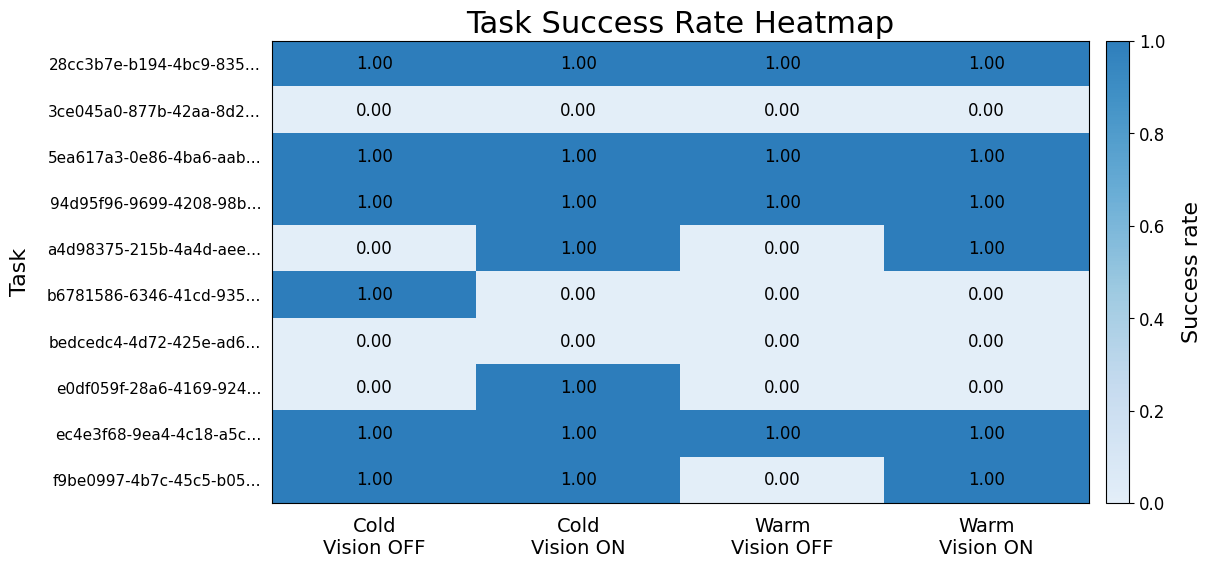

In [29]:
fig, ax, _ = plot_task_condition_success_heatmap_light_continuous(
    df_all,
    outpath_png=os.path.join(FIG_DIR, "heatmap_success_task_condition_light_continuous.png"),
    outpath_pdf=os.path.join(FIG_DIR, "heatmap_success_task_condition_light_continuous.pdf"),
    annotate=True,
    cell_fontsize=12,
    axis_label_fontsize=16,
    title = "Task Success Rate Heatmap"
)
plt.show()
plt.close(fig)

# Tasks difficulties

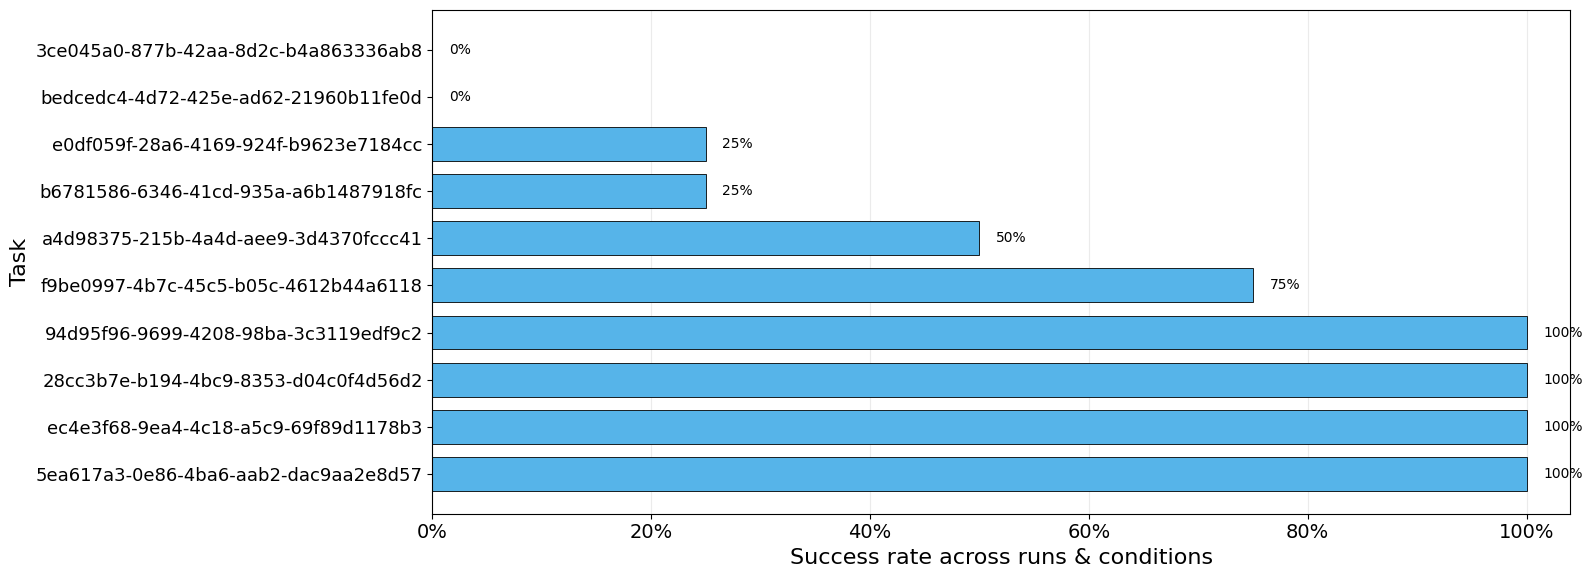

,task_id,success_rate,duration_mean,llm_mean,chunk_rate_mean,step_rate_mean,task_label
0,3ce045a0-877b-42aa-8d2c-b4a863336ab8,0.00,544.40700,30.00,0.300000,0.376096,3ce045a0-877b-42aa-8d2c-b4a863336ab8
1,bedcedc4-4d72-425e-ad62-21960b11fe0d,0.00,388.99350,26.00,0.516667,0.524369,bedcedc4-4d72-425e-ad62-21960b11fe0d
2,e0df059f-28a6-4169-924f-b9623e7184cc,0.25,632.07500,23.75,0.233333,0.643895,e0df059f-28a6-4169-924f-b9623e7184cc
3,b6781586-6346-41cd-935a-a6b1487918fc,0.25,510.17475,30.00,0.400000,0.463235,b6781586-6346-41cd-935a-a6b1487918fc
4,a4d98375-215b-4a4d-aee9-3d4370fccc41,0.50,403.23175,28.00,0.617857,0.628871,a4d98375-215b-4a4d-aee9-3d4370fccc41
5,f9be0997-4b7c-45c5-b05c-4612b44a6118,0.75,213.38300,16.00,0.906250,0.886364,f9be0997-4b7c-45c5-b05c-4612b44a6118
6,94d95f96-9699-4208-98ba-3c3119edf9c2,1.00,438.91800,28.75,0.506250,0.630994,94d95f96-9699-4208-98ba-3c3119edf9c2
7,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2,1.00,147.58475,10.00,1.000000,1.000000,28cc3b7e-b194-4bc9-8353-d04c0f4d56d2
8,ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3,1.00,129.35825,10.75,0.696429,0.791667,ec4e3f68-9ea4-4c18-a5c9-69f89d1178b3
9,5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57,1.00,92.99900,7.00,1.000000,1.000000,5ea617a3-0e86-4ba6-aab2-dac9aa2e8d57


In [30]:
fig_td, ax_td, task_prof = plot_task_difficulty_v3(
    df_all,
    task_col=TASK_COL,

    figsize=None,
    fig_width=16,
    row_height=0.55,
    min_fig_height=6.0,
    tight_layout_rect=(0, 0, 1, 0.98),

    task_label_max_chars=36,
    sort_by=("success_rate", "duration_mean"),
    sort_ascending=(True, False),

    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    bar_edgecolor="black",

    suptitle=None,
    suptitle_fontsize=24,
    panel_title=None, #"Task success profile",
    panel_title_fontsize=22,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xtick_fontsize=14,
    ytick_fontsize=13,
    annotation_fontsize=10,

    bar_height=0.72,
    bar_linewidth=0.6,
    bar_alpha=1.0,

    grid_alpha=0.25,
    xlim=(0.0, 1.04),
    show_reference_line=False,
    reference_line_value=None,
    reference_line_linestyle="--",
    reference_line_linewidth=1.5,
    reference_line_alpha=0.9,

    show_bar_values=True,
    bar_value_fmt="{:.0%}",
    bar_value_dx=0.015,

    outpath_png="figures_thesis/tasks_success_profile",
    outpath_pdf=None,
    save_dpi=350,
)

display(task_prof.head(20))

# Episode Cost

C:\Users\Luca\AppData\Local\Temp\ipykernel_8364\1399895426.py:1248: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=tight_layout_rect)


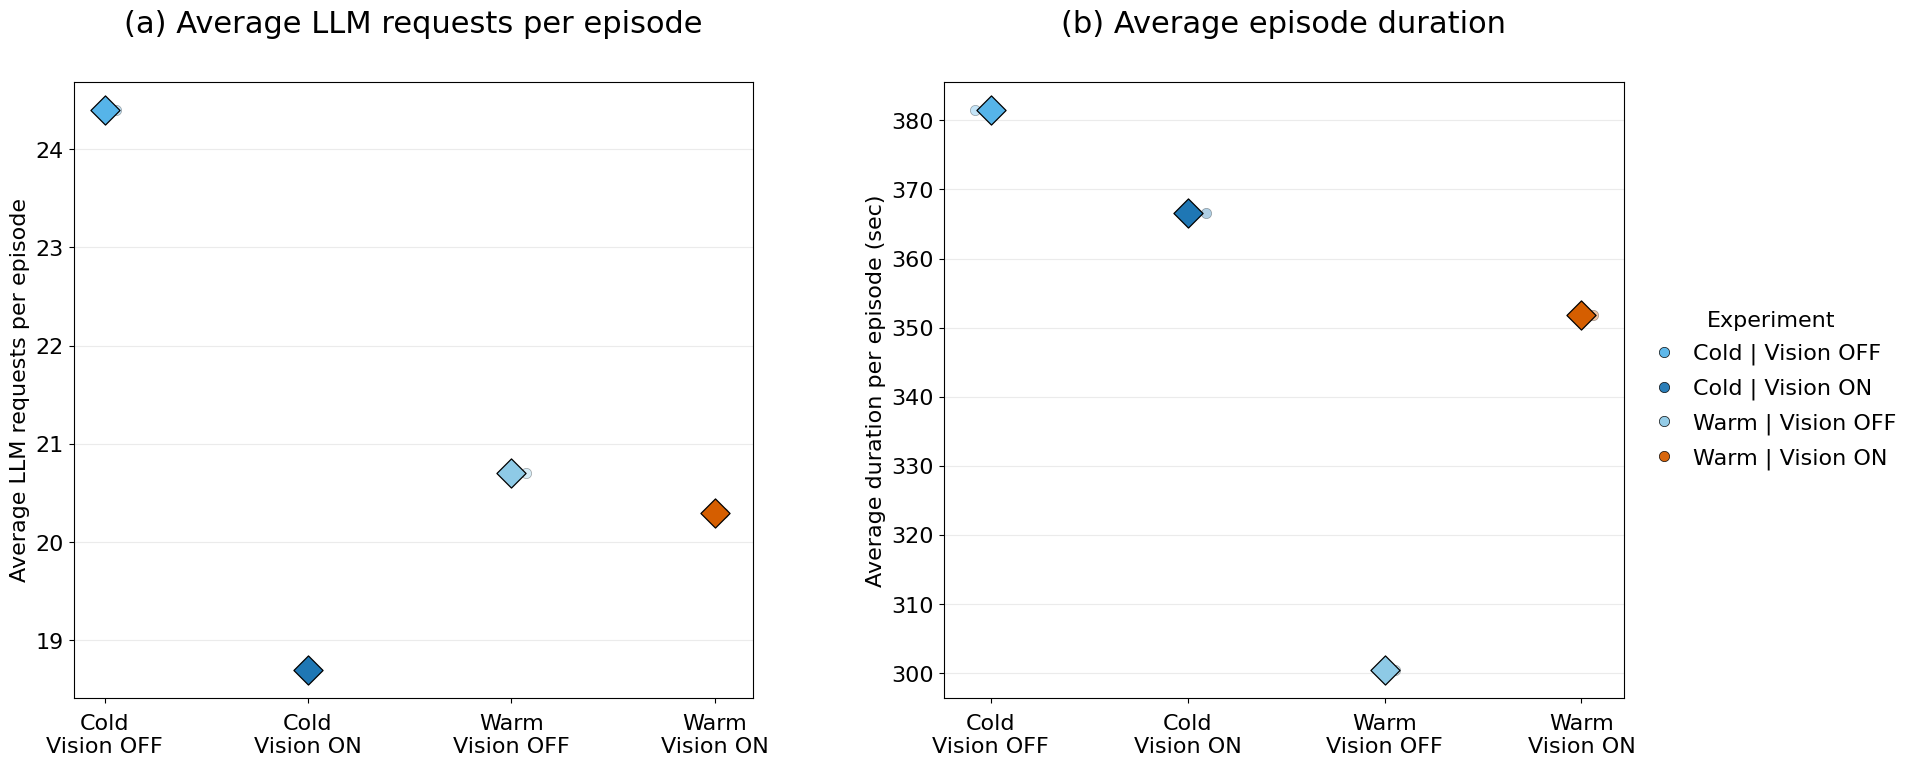

,condition_2x2,mean_llm_requests,std_llm_requests,mean_duration_sec,std_duration_sec,n_runs,total_episodes
0,Cold | Vision OFF,24.4,0.0,381.5223,0.0,1,10
1,Cold | Vision ON,18.7,0.0,366.6335,0.0,1,10
2,Warm | Vision OFF,20.7,0.0,300.4826,0.0,1,10
3,Warm | Vision ON,20.3,0.0,351.8116,0.0,1,10


In [20]:
fig_cost, axes_cost, run_cost_tbl, cost_summary_tbl = plot_episode_cost_dashboard_v3(
    df_all,
    cond_col=COND_COL,

    # output
    outpath_png=os.path.join(FIG_DIR, "episode_cost_dashboard_v3.png"),
    title=None,

    # layout generale
    figsize=(20, 8),
    nrows=1,
    ncols=2,
    wspace=0.28,
    hspace=0.20,
    tight_layout_rect=(0, 0, 0.88, 0.98),

    # marker / error bar / jitter
    point_size=55,
    point_alpha=0.35,
    point_edgecolor="black",
    point_linewidth=0.5,

    mean_marker="D",
    mean_marker_size=220,
    mean_alpha=1.0,
    mean_edgecolor="black",
    mean_linewidth=0.9,

    err_capsize=5,
    err_linewidth=1.2,
    jitter=0.10,
    random_seed=42,

    # colori
    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",
    fallback_cmap_name="tab10",

    # font
    suptitle_fontsize=24,
    panel_title_fontsize=22,
    xlabel_fontsize=16,
    ylabel_fontsize=16,
    xtick_fontsize=16,
    ytick_fontsize=16,
    legend_fontsize=16,
    legend_title_fontsize=16,

    # titoli / legenda
    suptitle_y=0.98,
    title_pad=0,
    title_y=1.08,

    show_legend=True,
    legend_title="Experiment",
    legend_loc="center left",
    legend_bbox_to_anchor=(1.02, 0.5),
    legend_frameon=False,
    legend_ncol=1,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,
    legend_borderaxespad=0.0,

    # labels pannelli
    title_left="(a) Average LLM requests per episode",
    title_right="(b) Average episode duration",
    xlabel=None,
    ylabel_left="Average LLM requests per episode",
    ylabel_right="Average duration per episode (sec)",

    # labels asse x
    xlabels_two_lines=True,
    xtick_rotation=0,
    xtick_pad=8,

    # assi / griglia
    grid_alpha=0.25,

    # salvataggio
    save_dpi=350,
)

display(cost_summary_tbl)
plt.show()
plt.close(fig_cost)

# Chunks quality

C:\Users\Luca\AppData\Local\Temp\ipykernel_8364\1399895426.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=tight_layout_rect)


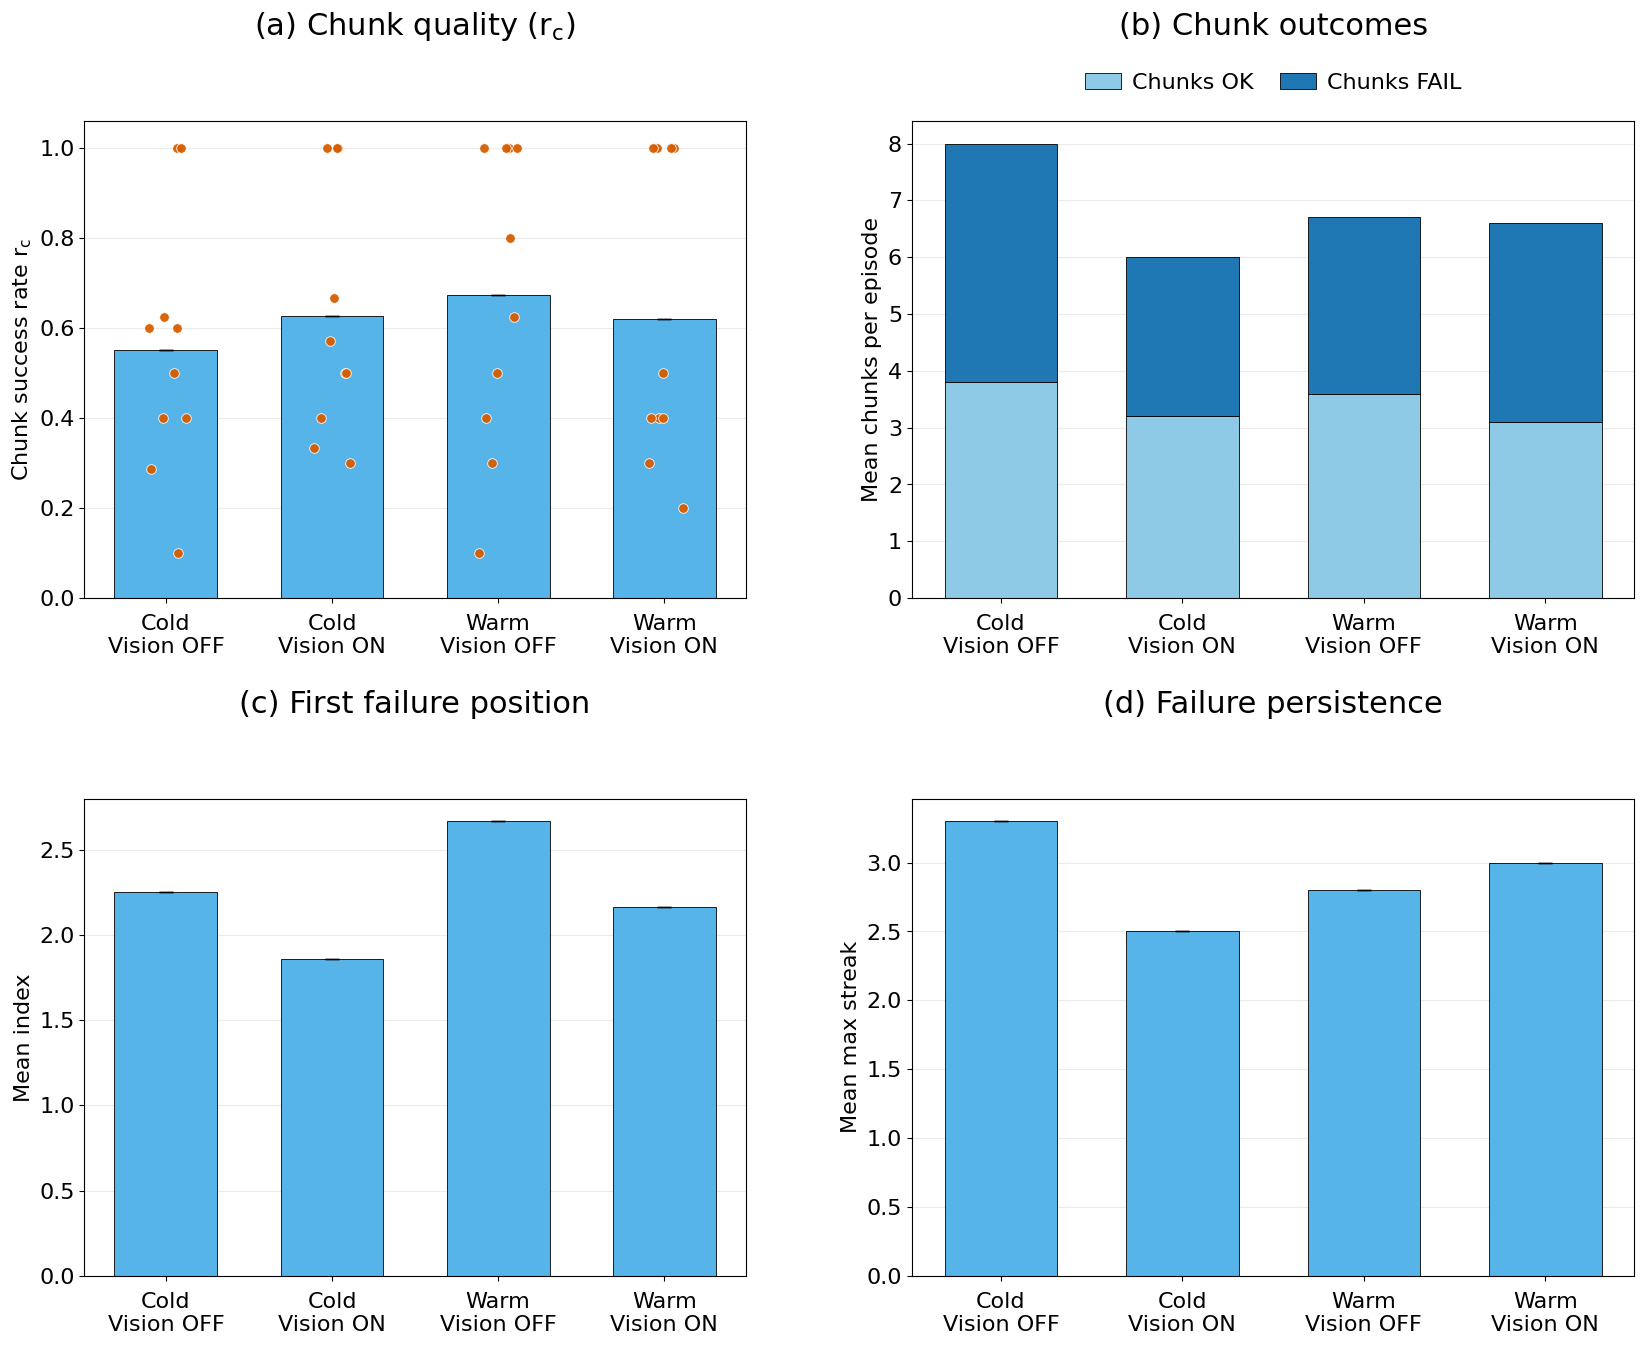

In [21]:
fig_chunk, axes_chunk = plot_chunk_dashboard_v3(
    df_all,
    outpath_png=os.path.join(FIG_DIR, "chunk_dashboard_v3.png"),
    outpath_pdf=os.path.join(FIG_DIR, "chunk_dashboard_v3.pdf"),
    title=None,

    figsize=(20, 15),
    width_ratios=(1.08, 1.18),
    height_ratios=(1.08, 1.08),
    hspace=0.42,
    wspace=0.24,
    tight_layout_rect=(0, 0, 1, 0.95),

    bar_width=0.62,
    bar_edgecolor="black",
    bar_linewidth=0.6,
    err_capsize=5,
    scatter_size=48,
    scatter_alpha=0.95,
    scatter_edgecolor="white",
    scatter_linewidth=0.6,
    jitter_frac=0.40,

    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",

    suptitle_fontsize=24,
    panel_title_fontsize=22,
    ylabel_fontsize=16,
    xtick_fontsize=16,
    ytick_fontsize=16,
    legend_fontsize=16,

    suptitle_y=0.98,
    title_pad=0,
    title_y=1.18,
    legend_outside=True,
    legend_y=1.08,
    legend_ncol=2,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,

    xlabels_two_lines=True,

    xtick_rotation=0,
    xtick_pad=8,
    grid_alpha=0.25,
    ypad_top=0.06,
    ylim_a_max=1.15,

    save_dpi=350,
)

plt.show()
plt.close(fig_chunk)

# Steps quality

C:\Users\Luca\AppData\Local\Temp\ipykernel_8364\1399895426.py:675: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, right_margin, 1])


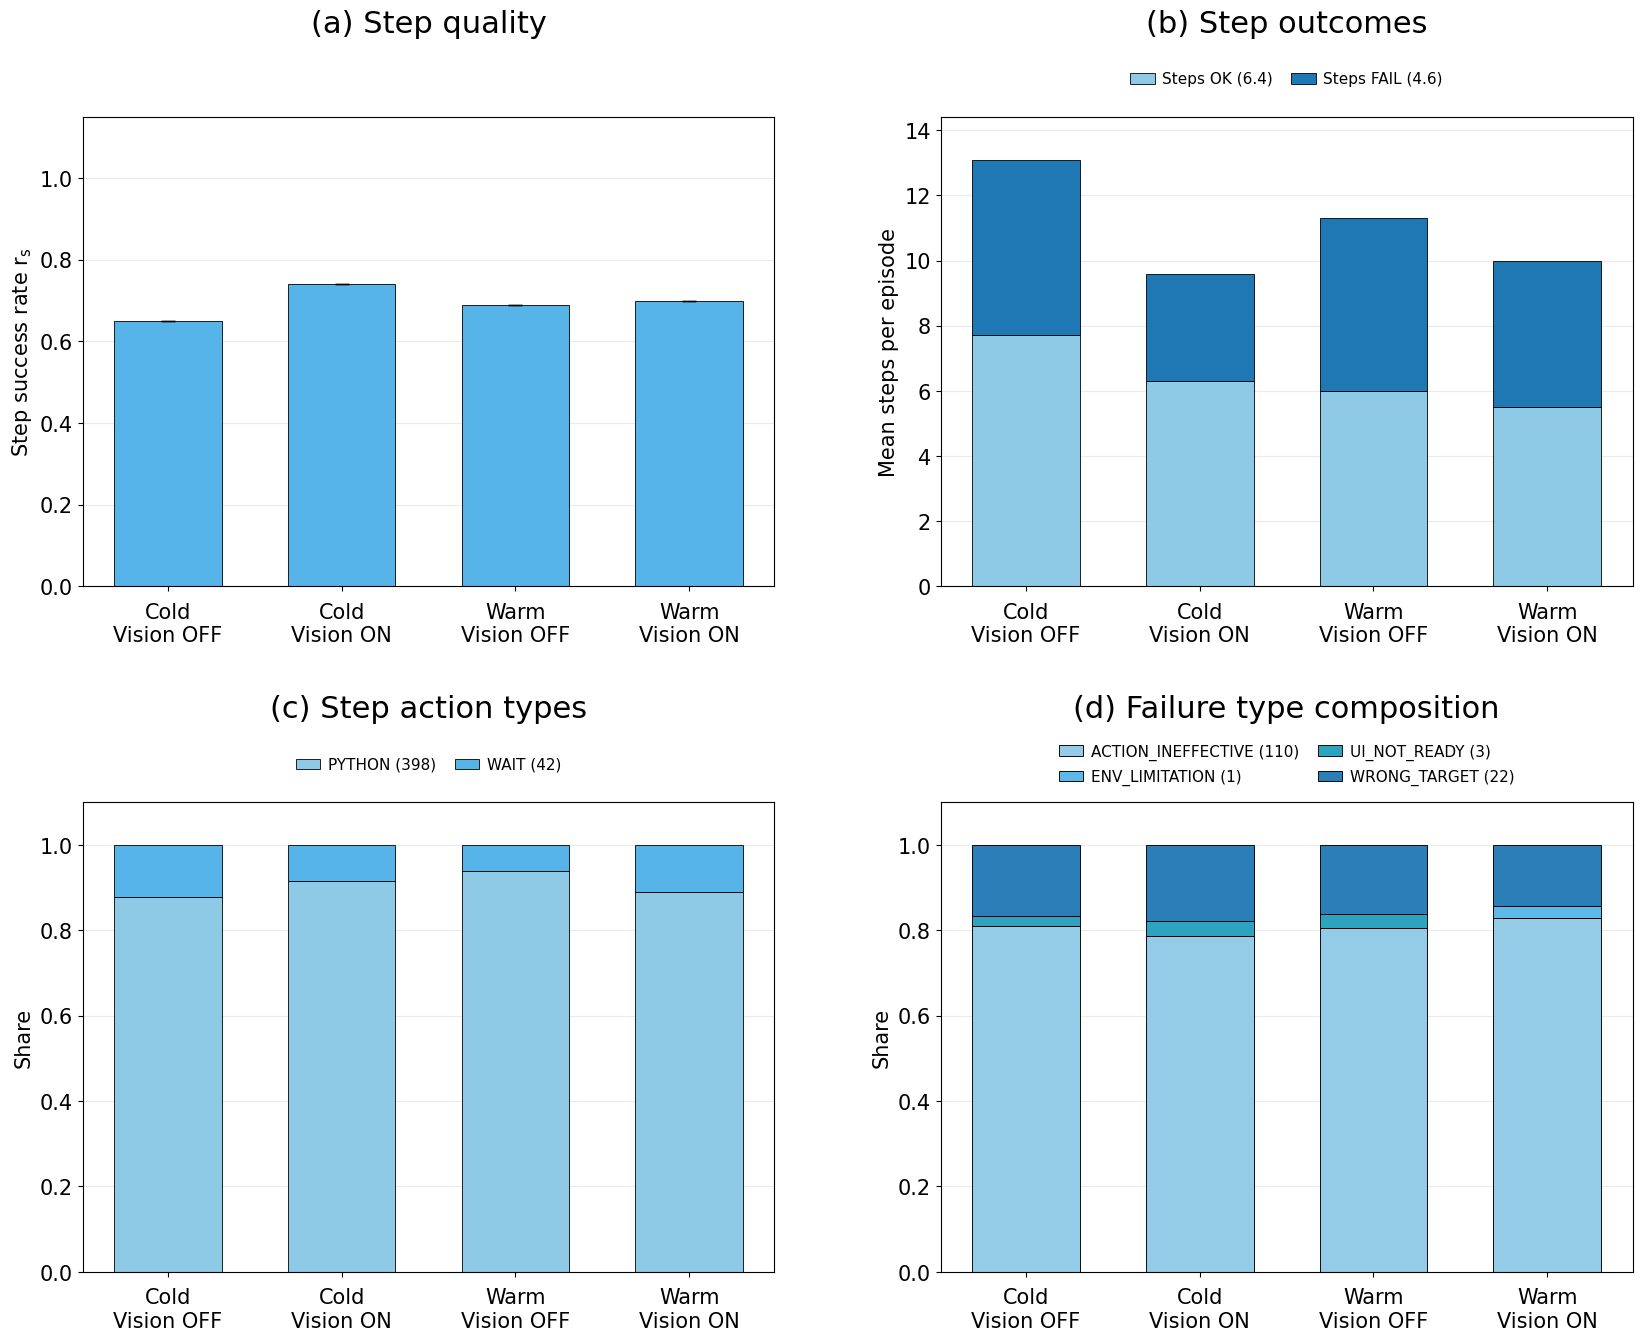

failure_type,ACTION_INEFFECTIVE,ENV_LIMITATION,UI_NOT_READY,WRONG_TARGET
condition_2x2,,,,
Cold | Vision OFF,0.809524,0.000000,0.023810,0.166667
Cold | Vision ON,0.785714,0.000000,0.035714,0.178571
Warm | Vision OFF,0.806452,0.000000,0.032258,0.161290
Warm | Vision ON,0.828571,0.028571,0.000000,0.142857


,Condition,Step success rate $r_s$,Steps evaluated,Steps OK,Steps FAIL,WAIT share,PYTHON share,Avg pause/step (s),LLM calls
0,Cold | Vision OFF,65.0%,13.1,7.7,5.4,12.2%,87.8%,3.32,24.4
1,Cold | Vision ON,74.0%,9.6,6.3,3.3,8.3%,91.7%,3.46,18.7
2,Warm | Vision OFF,69.0%,11.3,6.0,5.3,6.2%,93.8%,3.46,20.7
3,Warm | Vision ON,69.9%,10.0,5.5,4.5,11.0%,89.0%,3.64,20.3


In [22]:
fig_steps, axes_steps, failure_tbl = plot_steps_dashboard_v8(
    df_all,
    cond_col=COND_COL,
    legend_fontsize=11,
    legend_ncol=2,
    legend_outside=True
)
steps_tbl = build_steps_summary_table(df_all, cond_col="condition_2x2")

display(failure_tbl)
steps_tbl

# Chunks Errors

C:\Users\Luca\AppData\Local\Temp\ipykernel_8364\1399895426.py:1559: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=tight_layout_rect)


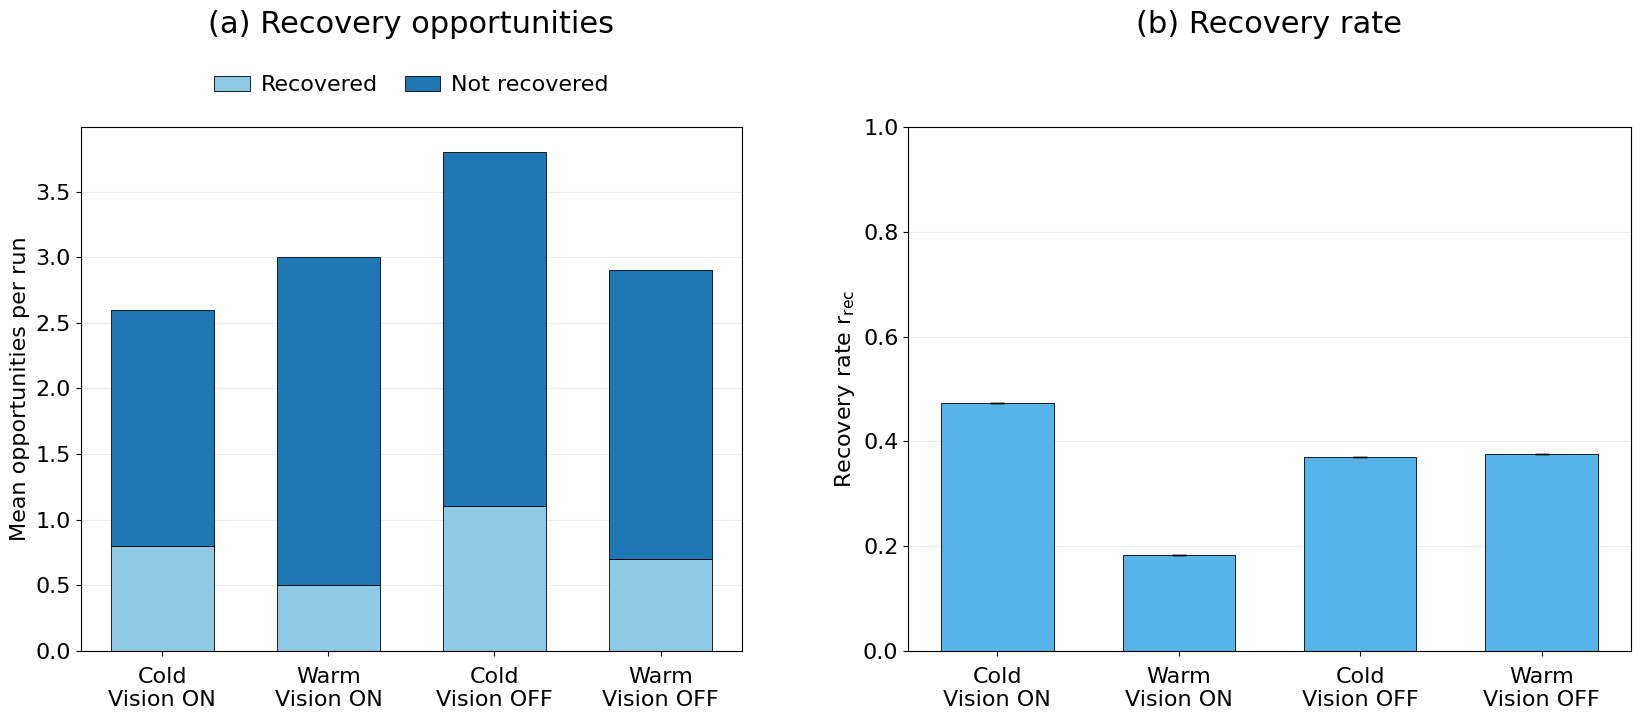

In [23]:
fig_err, axes_err, recovery_tbl = plot_error_dashboard_v3(
    df_all,

    cond_col=COND_COL,
    sort_col="exp_sort",
    run_col="run_id",

    outpath_png=os.path.join(FIG_DIR, "error_dashboard_v3.png"),
    title=None,

    figsize=(20, 6.8),
    width_ratios=(1.08, 1.18),
    hspace=0.42,
    wspace=0.24,
    tight_layout_rect=(0, 0, 1, 0.95),

    bar_width=0.62,
    bar_edgecolor="black",
    bar_linewidth=0.6,
    err_capsize=5,
    err_linewidth=1.2,

    show_run_scatter=False,
    scatter_size=48,
    scatter_alpha=0.95,
    scatter_edgecolor="white",
    scatter_linewidth=0.6,
    jitter_frac=0.40,
    random_seed=42,

    main_blue="#56B4E9",
    contrast_orange="#D55E00",
    blue_light="#8ECAE6",
    blue_dark="#1F77B4",

    suptitle_fontsize=24,
    panel_title_fontsize=22,
    ylabel_fontsize=16,
    xtick_fontsize=16,
    ytick_fontsize=16,
    legend_fontsize=16,
    legend_title_fontsize=16,

    suptitle_y=0.98,
    title_pad=0,
    title_y=1.18,

    legend_outside=True,
    legend_y=1.08,
    legend_loc="center",
    legend_ncol=2,
    legend_columnspacing=1.2,
    legend_handlelength=1.6,
    legend_handletextpad=0.5,
    legend_labelspacing=0.6,

    title_A="(a) Recovery opportunities",
    title_B="(b) Recovery rate",

    ylabel_A="Mean opportunities per run",
    ylabel_B="Recovery rate $r_{rec}$",

    xlabels_two_lines=True,
    xtick_rotation=0,
    xtick_pad=8,

    grid_alpha=0.25,
    ypad_top=0.06,
    ylim_rate=(0.0, 1.0),

    save_dpi=350,
)